# UNIVERSIDAD PERUANA DE CIENCIAS APLICADAS – UPC  
## CARRERA PROFESIONAL: CIENCIAS DE LA COMPUTACIÓN  
### PRÁCTICA CALIFICADA 02  
### Curso: Data Mining Tools  
### Docente: Ph.D. Carlos Fernando Montoya Cubas  
### Semestre: 2025-02  
### Duración: 200 minutos  
### Modalidad: Grupal  
### Total: 20 puntos  

---

## PRÁCTICA CALIFICADA 02 – Clustering y Selección de Características  

**Indicaciones generales:**  
- Trabajo en equipos según indicaciones del docente.  
- Completar todas las secciones en este notebook.  
- Justificar siempre sus decisiones (selección de métodos, parámetros, etc.).  
- Usar gráficos y tablas cuando sea pertinente.  
- Comentar el código para facilitar la lectura.


---
# PARTE A – CLUSTERING (10 puntos)

**Dataset requerido (Clustering): Customer Personality Analysis (Kaggle)**  
Incluye valores faltantes y variables mixtas.  

**Enlace directo al dataset:**  
 https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis  



## Pregunta A1 (5 puntos): Preprocesamiento, imputación y preparación de datos

**Objetivo:** Realizar una limpieza y preparación adecuada del dataset antes de aplicar algoritmos de clustering.

### Tareas obligatorias

1. **Auditoría de datos:**
   - Calcular el porcentaje de valores faltantes por columna.
   - Identificar variables numéricas y categóricas.
   - Detectar posibles *outliers* en las variables numéricas (breve análisis descriptivo o gráfico).

2. **Imputación comparada de valores faltantes:**
   - Aplicar `SimpleImputer` (media o mediana según corresponda).
   - Aplicar `KNNImputer`.
   - Comparar los resultados y comentar cuál método consideras más adecuado para este dataset y por qué.

3. **Escalamiento comparado:**
   - Probar `StandardScaler`.
   - Probar `MinMaxScaler`.
   - Comentar brevemente las diferencias observadas en la distribución de los datos.

4. **Codificación de variables categóricas:**
   - Aplicar One Hot Encoding a las variables categóricas seleccionadas.

### Entregables A1

- Tablas o resúmenes antes y después de la imputación.
- Breve comparación escrita entre los métodos de imputación y de escalamiento elegidos.
- Explicación clara y concisa de las decisiones tomadas.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### A1.1 Carga del dataset y auditoría inicial

In [181]:
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Administrador\.cache\kagglehub\datasets\imakash3011\customer-personality-analysis\versions\1


In [182]:
destino = os.getcwd()
if os.path.exists(path):
    try:
        os.makedirs(os.path.dirname(destino), exist_ok=True)
        shutil.move(path, destino)
        print(f"Archivo movido a: {destino}")
    except Exception as e:
        print(f"Error al mover el archivo: {e}")
else:
    print("El archivo original no existe.")

Error al mover el archivo: Destination path 'd:\Ciclo VIII\Data Mining Tools\notebooks\1' already exists


In [183]:
# A1.1 Carga del dataset y exploración inicial
import pandas as pd

df = pd.read_csv('./1/marketing_campaign.csv', sep='\t')

# Mostrar información general
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### A1.2 Imputación de valores faltantes (SimpleImputer vs KNNImputer)

In [ ]:
# A1.2 Imputación de valores faltantes
from sklearn.impute import SimpleImputer, KNNImputer

# Separar variables numéricas y categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Implementar aquí los dos esquemas de imputación y comparar
# Esquema 1: Imputación simple
simple_imputer = SimpleImputer(strategy='mean')
df[num_cols] = simple_imputer.fit_transform(df[num_cols])

# Esquema 2: Imputación KNN
knn_imputer = KNNImputer(n_neighbors=5)
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

# Comparar resultados
print("Valores faltantes después de la imputación:")
print(df.isnull().sum())


Valores faltantes después de la imputación:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


### A1.3 Escalamiento (StandardScaler vs MinMaxScaler)

In [185]:
# A1.3 Aplicar y comparar StandardScaler y MinMaxScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Inicializamos los escaladores
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

# Creamos copias del DataFrame para cada escalador
df_std = df.copy()
df_mm = df.copy()

# StandardScaler y MinMaxScaler
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])

# Comparar resultados
print("StandardScaler - Descripción estadística:")
print(df_std[num_cols].describe())
print("\nMinMaxScaler - Descripción estadística:")
print(df_mm[num_cols].describe())


StandardScaler - Descripción estadística:
                 ID    Year_Birth        Income       Kidhome      Teenhome  \
count  2.240000e+03  2.240000e+03  2.240000e+03  2.240000e+03  2.240000e+03   
mean   2.220446e-17 -8.133970e-15  5.154607e-17 -1.586033e-17 -3.172066e-18   
std    1.000223e+00  1.000223e+00  1.000223e+00  1.000223e+00  1.000223e+00   
min   -1.722818e+00 -6.326960e+00 -2.018090e+00 -8.252176e-01 -9.298944e-01   
25%   -8.514982e-01 -8.184192e-01 -6.674801e-01 -8.252176e-01 -9.298944e-01   
50%   -4.117757e-02  9.967091e-02 -2.020403e-02 -8.252176e-01 -9.298944e-01   
75%    8.735813e-01  6.839101e-01  6.408743e-01  1.032559e+00  9.069340e-01   
max    1.724876e+00  2.269702e+00  2.454513e+01  2.890335e+00  2.743762e+00   

            Recency      MntWines     MntFruits  MntMeatProducts  \
count  2.240000e+03  2.240000e+03  2.240000e+03     2.240000e+03   
mean  -3.172066e-18 -7.612958e-17 -2.379049e-17     4.123686e-17   
std    1.000223e+00  1.000223e+00  1.00022

### A1.4 Codificación de categóricas (One Hot Encoding)

In [186]:
from sklearn.preprocessing import OneHotEncoder

# A1.4 One Hot Encoding
OHE = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = OHE.fit_transform(df[cat_cols])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=OHE.get_feature_names_out(cat_cols))
df_final = pd.concat([df[num_cols], cat_encoded_df], axis=1)
print("DataFrame final después de One Hot Encoding:")
print(df_final.head())


DataFrame final después de One Hot Encoding:
       ID  Year_Birth   Income  Kidhome  Teenhome  Recency  MntWines  \
0  5524.0      1957.0  58138.0      0.0       0.0     58.0     635.0   
1  2174.0      1954.0  46344.0      1.0       1.0     38.0      11.0   
2  4141.0      1965.0  71613.0      0.0       0.0     26.0     426.0   
3  6182.0      1984.0  26646.0      1.0       0.0     26.0      11.0   
4  5324.0      1981.0  58293.0      1.0       0.0     94.0     173.0   

   MntFruits  MntMeatProducts  MntFishProducts  ...  Dt_Customer_31-03-2014  \
0       88.0            546.0            172.0  ...                     0.0   
1        1.0              6.0              2.0  ...                     0.0   
2       49.0            127.0            111.0  ...                     0.0   
3        4.0             20.0             10.0  ...                     0.0   
4       43.0            118.0             46.0  ...                     0.0   

   Dt_Customer_31-05-2013  Dt_Customer_31-05-20

### A1.5 Conclusiones de preprocesamiento
Escribe aquí tus conclusiones sobre:
- Método de imputación elegido y por qué.
- Tipo de escalamiento seleccionado y su justificación.
- Impacto general del preprocesamiento sobre los datos.

---
## Pregunta A2 (5 puntos): Clustering usando K-Means, EM (GMM), DBSCAN y Jerárquico

**Objetivo:** Aplicar distintos algoritmos de clustering y comparar su desempeño sobre el dataset preprocesado.

### Tareas obligatorias

1. **Selección del número de clusters (cuando aplique):**
   - Utilizar *Elbow Method* para sugerir un rango de posibles números de clusters.
   - Calcular el *Silhouette Score* para distintos valores de k y elegir un número adecuado de clusters.

2. **Aplicar los 4 algoritmos de clustering:**
   - K-Means++
   - Gaussian Mixture Models (EM/GMM)
   - DBSCAN
   - Clustering Jerárquico (método de enlace Ward)

3. **Evaluación y comparación:**
   - Calcular para cada modelo (cuando corresponda):
     - Silhouette Score
     - Davies–Bouldin Index
   - Proyectar los datos a 2 dimensiones usando PCA y graficar los clusters para cada algoritmo.

4. **Análisis:**
   - Discutir qué algoritmo produce agrupamientos más coherentes para este problema.
   - Indicar si DBSCAN detecta ruido (*outliers*) de manera razonable.
   - Comentar brevemente diferencias entre clusters esféricos (K-Means), elípticos (GMM) y arbitrarios (DBSCAN).

### Entregables A2

- Gráficos de *Elbow* y *Silhouette*.
- Gráficos de clusters en 2D (PCA) para cada algoritmo.
- Tabla comparativa de métricas internas.
- Conclusión técnica argumentada.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### A2.1 Selección del número de clusters (Elbow & Silhouette)

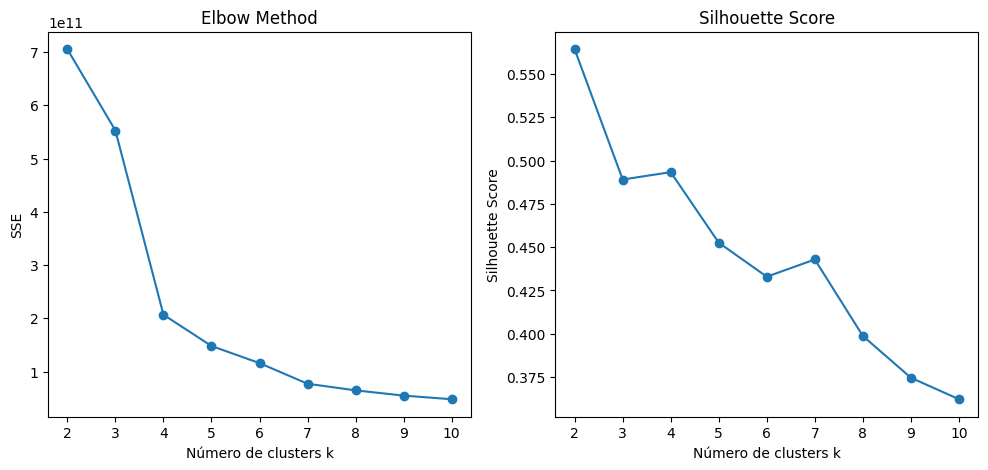

In [187]:
# A2.1 Cálculo de Elbow y Silhouette para K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Implementar aquí el barrido de k y los gráficos
sse = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_final)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_final, labels))

# Gráfico de Elbow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Número de clusters k')
plt.ylabel('SSE')



# Gráfico de Silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')

plt.show()

### A2.2 Aplicación de K-Means, GMM, DBSCAN y Jerárquico

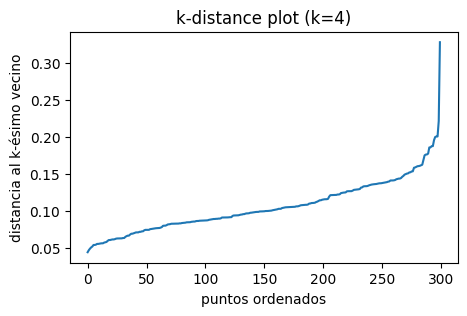

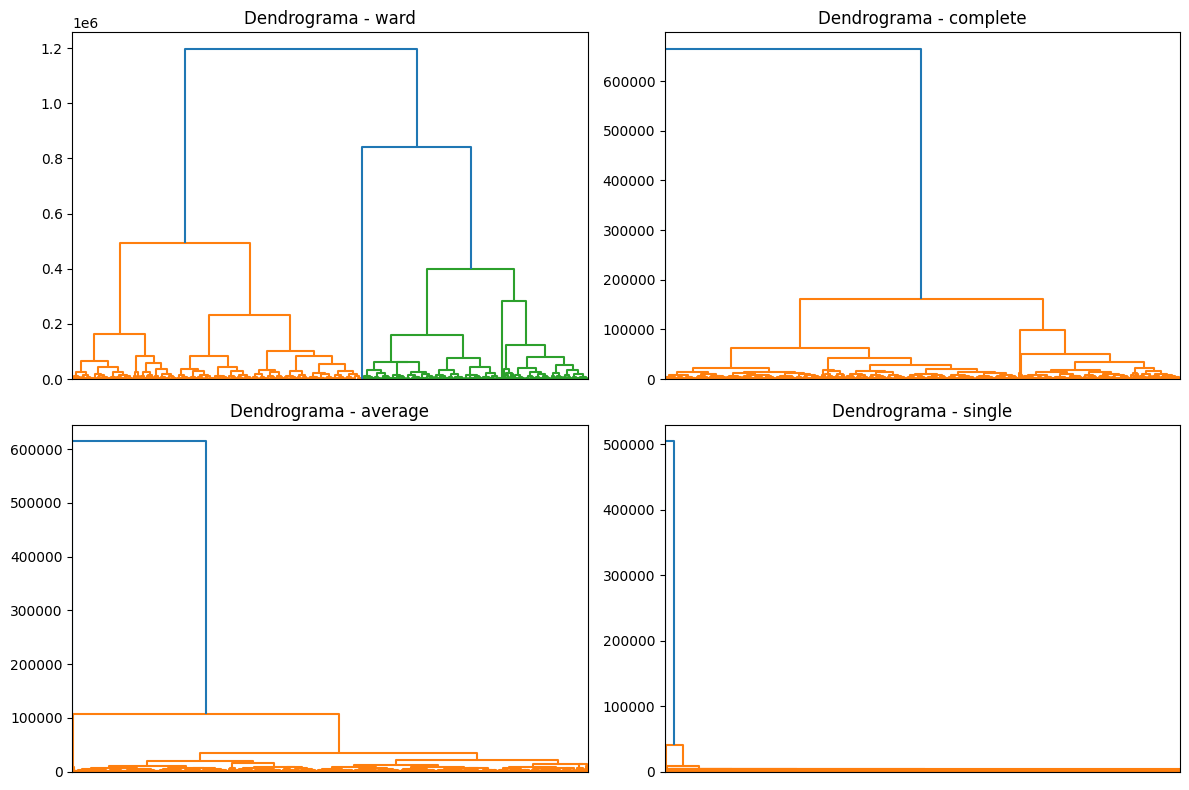

In [188]:
# A2.2 Clustering con los 4 algoritmos
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# Ajustar aquí los modelos usando los datos preprocesados
k = 4  # Número de clusters basado en análisis previo

# K-Means
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(df_final)

# Gaussian Mixture Models
gmm = GaussianMixture(n_components=k, random_state=42)
gmm_labels = gmm.fit_predict(df_final)

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=9)
dbscan_labels = dbscan.fit_predict(df_final)

X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

pca_moons = PCA(n_components=2)
X_moons_2d = pca_moons.fit_transform(X_moons_scaled)

def k_distance_plot(X, k=4):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kth_dist = np.sort(dists[:, -1])
    plt.figure(figsize=(5,3))
    plt.plot(kth_dist)
    plt.title(f"k-distance plot (k={k})")
    plt.xlabel("puntos ordenados")
    plt.ylabel("distancia al k-ésimo vecino")
    plt.show()

k_distance_plot(X_moons_scaled, k)


# Clustering Jerárquico
linkage_methods = ["ward", "complete", "average", "single"]
linkages = {}

for m in linkage_methods:
    Z = linkage(df_final, method=m)
    linkages[m] = Z

plt.figure(figsize=(12,8))

for i, m in enumerate(linkage_methods, start=1):
    plt.subplot(2,2,i)
    dendrogram(linkages[m], no_labels=True)
    plt.title(f"Dendrograma - {m}")

plt.tight_layout()
plt.show()

labels_hierarchical = {}
for m in linkage_methods:
    Z = linkages[m]
    hierarchical_labels = fcluster(linkages["ward"], t=k, criterion='maxclust')
    labels_hierarchical[m] = hierarchical_labels

### A2.3 Visualización en 2D con PCA

<Figure size 1200x1000 with 0 Axes>

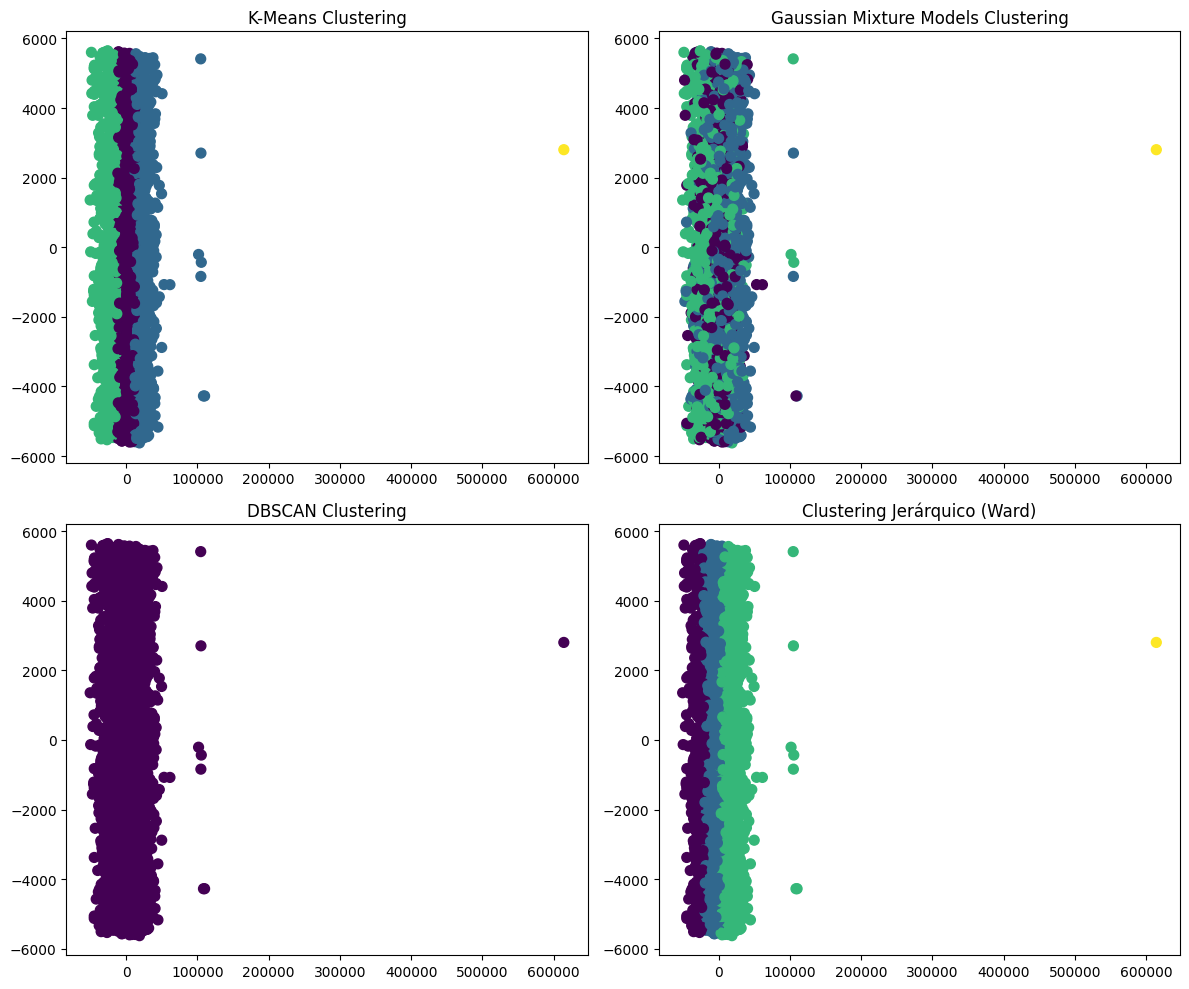

In [ ]:
# A2.3 PCA y gráficos de clusters
from sklearn.decomposition import PCA

# Implementar PCA y graficar los resultados para cada algoritmo
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
plt.figure(figsize=(12, 10))

# K-Means
plt.subplot(2, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means Clustering')


# Gaussian Mixture Models
plt.subplot(2, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=gmm_labels, cmap='viridis', s=50)
plt.title('Gaussian Mixture Models Clustering')

# DBSCAN
plt.subplot(2, 2, 3)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clustering')

# Clustering Jerárquico (usando 'ward')
plt.subplot(2, 2, 4)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_hierarchical['ward'], cmap='viridis', s=50)
plt.title('Clustering Jerárquico (Ward)')

plt.tight_layout()
plt.show()

### A2.4 Cálculo de métricas y comparación

In [ ]:
# A2.4 Cálculo de Silhouette y Davies–Bouldin para cada algoritmo
from sklearn.metrics import davies_bouldin_score

# Calcular métricas y organizarlas en una tabla
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

def safe_silhouette_score(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    return silhouette_score(X, labels)

def safe_davies_bouldin_score(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    return davies_bouldin_score(X, labels)

metrics = {
    'K-Means': {
        'Silhouette': safe_silhouette_score(df_final, kmeans_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df_final, kmeans_labels)
    },
    'Gaussian Mixture': {
        'Silhouette': safe_silhouette_score(df_final, gmm_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df_final, gmm_labels)
    },
    'DBSCAN': {
        'Silhouette': safe_silhouette_score(df_final, dbscan_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df_final, dbscan_labels)
    },
    'Hierarchical (Ward)': {
        'Silhouette': safe_silhouette_score(df_final, labels_hierarchical['ward']),
        'Davies-Bouldin': safe_davies_bouldin_score(df_final, labels_hierarchical['ward'])
    }
}


In [193]:
comparison_df = pd.DataFrame(metrics).T
print("Comparación de métricas de clustering:")
print(comparison_df)

Comparación de métricas de clustering:
                     Silhouette  Davies-Bouldin
K-Means                0.493369        0.472835
Gaussian Mixture       0.034940        1.920403
DBSCAN                      NaN             NaN
Hierarchical (Ward)    0.473722        0.485620


### A2.5 Conclusiones sobre los algoritmos de clustering
Escribe aquí tus conclusiones comparando K-Means, GMM, DBSCAN y Jerárquico en términos de:
- Calidad de clusters (métricas).
- Capacidad de detectar ruido.
- Interpretabilidad de los resultados.


**CONCLUSIONES**
- K-Means y Clustering jerarquico demostraron mejor calidad de agrupamiento según las métricas de Silhouette (entre 0.47 y 0.49) y Davies-Bouldin(entre 0.47 y 0.48) indicando clusters moderadamente bien separados y compactos. 

- Ninguno de los algoritmos probados demostró una gran capacidad efectiva para manejar ruido en los datos. Por ejemplo, DBSCAN falló completamente al devolver valores NaN, lo que sugiere que no pudo formar clusters válidos posiblemente clasificando todos los puntos como ruido o formó un único cluster. Tanto K-Means como Clustering jerarquico, al ser algoritmos que asignan forzosamente cada punto a un cluster, carecen de mecanismos inherentes para identificar y separar valores atípicos. Y Gaussian Mixture, aunque teóricamente puede manejar outliers mediante probabilidades, mostró un desempeño fuera de lo esperado.

- K-Means se consolida como el método más interpretable debido a su naturaleza basada en centroides y clusters esféricos, facilitando su comprensión y explicación de los grupos identificados. De igual manera clustering jerarquico también ofrece buena interpretabilidad a través de su estructura previamente analizada adicionalmento por dendrogramas que revela relaciones jerárquicas entre los clusters. Posteriormente , Gaussian Mixture siendo un modelo probabilístico, presenta cierta mayor complejidad para interpretar. Por ultimo, la completa falta de resultados de DBSCAN al final imposibilitó cualquier análisis interpretativo.

---
# PARTE B – SELECCIÓN DE CARACTERÍSTICAS (10 puntos)

**Dataset requerido (Selección de Características): Stroke Prediction Dataset (Kaggle)**  
Incluye valores faltantes, variables mixtas y desbalance de clases.

**Enlace directo al dataset:**  
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  

---


## Pregunta B1 (5 puntos): Preprocesamiento, imputación y selección preliminar

**Objetivo:** Preparar el dataset para modelos supervisados y realizar una primera selección de características basada en métodos filtro.

### Tareas

1. **Reporte de valores faltantes:**
   - Mostrar una tabla con el porcentaje de NA por columna.
   - Visualizar con un heatmap (opcional).

2. **Imputación comparada:**
   - Aplicar `SimpleImputer`.
   - Aplicar `IterativeImputer` (MICE).
   - Comparar brevemente ambos métodos y justificar cuál decides usar en el resto de la práctica.

3. **Análisis de correlación:**
   - Calcular matriz de correlación entre variables numéricas.
   - Identificar características redundantes (correlación |r| > 0.8) y proponer cuáles podrían eliminarse.

4. **Codificación categórica:**
   - Aplicar One Hot Encoding a las variables categóricas.

5. **Métodos filtro de selección de características:**
   - Aplicar ANOVA F-test o Chi-cuadrado (según tipo de variable objetivo).
   - Aplicar Mutual Information.
   - Comparar los rankings obtenidos y comentar similitudes/diferencias.

### Entregables B1

- Resumen de NA e imputación.
- Matriz de correlación y variables redundantes.
- Ranking de características según métodos filtro.
- Justificación del conjunto preliminar de características seleccionadas.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### B1.1 Carga del dataset y análisis de valores faltantes

In [ ]:
# B1.1 Cargar dataset de Stroke Prediction
df_stroke = None  # Cargar aquí el dataset descargado desde Kaggle

# Analizar valores faltantes


### B1.2 Imputación (SimpleImputer vs IterativeImputer)

In [ ]:
# B1.2 Imputación de valores faltantes
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer

# Implementar y comparar ambos esquemas de imputación


### B1.3 Correlación y variables redundantes

In [ ]:
# B1.3 Matriz de correlación y detección de alta correlación
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular y visualizar matriz de correlación


### B1.4 One Hot Encoding y preparación de X, y

In [ ]:
# B1.4 One Hot Encoding y separación de variables predictoras (X) y objetivo (y)


### B1.5 Métodos filtro (ANOVA / Chi2 / Mutual Information)

In [ ]:
# B1.5 Selección por métodos filtro
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif

# Implementar aquí el cálculo de scores y ranking de características


### B1.6 Conclusiones de selección preliminar
Escribe aquí tus conclusiones sobre:
- Método de imputación elegido.
- Variables que podrían eliminarse por alta correlación.
- Subconjunto preliminar de características relevantes según métodos filtro.


---
## Pregunta B2 (5 puntos): Selección de características avanzada e impacto en clasificación

**Objetivo:** Aplicar métodos wrapper y embedded para selección de características, y evaluar su impacto en el rendimiento de modelos supervisados.

### Tareas

1. **Métodos wrapper (RFE):**
   - Aplicar `RFE` con Logistic Regression.
   - Aplicar `RFE` con Random Forest.
   - Comparar los subconjuntos de características obtenidos.

2. **Métodos embedded:**
   - Aplicar Lasso (L1) y observar qué coeficientes se aproximan a cero.
   - Calcular importancia de características con Random Forest (`feature_importances_`).

3. **Construcción de un subconjunto final de características:**
   - Proponer un subconjunto final de características combinando la evidencia de filtros, RFE y métodos embedded.
   - Justificar por qué ese subconjunto es razonable.

4. **Evaluación del impacto en modelos de clasificación:**
   - Entrenar Logistic Regression y Random Forest en dos escenarios:
     1. Usando todas las características.
     2. Usando únicamente el subconjunto seleccionado.
   - Evaluar con: Accuracy, F1-score, ROC-AUC (en validación o test).

5. **Análisis final:**
   - Discutir si la selección de características mejora la generalización, la simplicidad del modelo o ambas.
   - Comentar si se observa sobreajuste cuando se usan todas las características.

### Entregables B2

- Comparación de subconjuntos seleccionados por RFE, Lasso y Random Forest.
- Tabla de métricas en los dos escenarios (todas las features vs subconjunto).
- Gráfico de importancia de características (barplot recomendado).
- Conclusión técnica bien argumentada.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### B2.1 RFE con Logistic Regression y Random Forest

In [ ]:
# B2.1 Aplicar RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Definir modelos base y aplicar RFE


### B2.2 Métodos embedded (Lasso y Random Forest Importance)

In [ ]:
# B2.2 Lasso y Random Forest Importance
from sklearn.linear_model import Lasso

# Ajustar modelos y obtener importancias/coefs


### B2.3 Definición del subconjunto final de características

In [ ]:
# B2.3 Combinar resultados de filtros, RFE y embedded para elegir un subconjunto final


### B2.4 Evaluación de modelos con todas las características vs subconjunto

In [ ]:
# B2.4 Entrenar y evaluar Logistic Regression y Random Forest
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Separar train/test y evaluar ambos escenarios


### B2.5 Conclusiones finales de la práctica
Escribe aquí tus conclusiones generales sobre:
- El efecto del preprocesamiento y la imputación.
- Las diferencias entre los algoritmos de clustering.
- La importancia de la selección de características en modelos supervisados.


---
# RÚBRICA GLOBAL – 20 puntos

| Parte | Pregunta | Ejecución (2 pts) | Análisis (3 pts) | Total |
|------|-----------|------------------|------------------|--------|
| A    | A1        | 2                | 3                | 5      |
| A    | A2        | 2                | 3                | 5      |
| B    | B1        | 2                | 3                | 5      |
| B    | B2        | 2                | 3                | 5      |

**Nota:** La calidad de las conclusiones, la claridad de los gráficos y la correcta justificación de las decisiones metodológicas tendrán un peso importante dentro de la sección de análisis.
